<div class="alert alert-block alert-success">


# **04 — correlation relationship analysis**

## **Goal of this notebook**
The goal is to explore relationships between variables visually and at surface level. This notebook is exploratory, not confirmatory — when a pattern appears interesting it gets flagged, and flagged patterns become the hypotheses tested with statistical rigor in notebook 05. Three types of relationships are examined: numerical vs numerical (correlation), categorical vs categorical (cross-tabulation), and numerical vs categorical (group comparison). **No conclusions are drawn here — only observations**.

### **Visualizations in this notebook:**
- Numerical and categorical univariate plots
- Numerical and categorical bivariate plots
- hybrid trivariate plots 
- correlation heatmap plots 
- comparative plots 

In [ ]:
# importing the necessaries
import sys
import os
import pandas as pd
# Adding the root to the path to use utils folder
sys.path.append(os.path.abspath(os.path.join('..')))

from utils.db_utils import run_query 
from utils.custom_plots import (distribution_plot, 
                                box_plot,
                                correlation_heatmap,
                                scatter_plot,
                                cross_tab_heatmap,
                                bubble_plot)

from utils.schema_diagram import schema_diagram


import plotly.io as pio
pio.renderers.default = "png" # drop these 2 lines if you want interactive charts locally

# we will add the findings to the below dict to test statistically in the next notebook
findings = dict()
findings['title'] = 'description'
findings['national team players effect'] = 'test if teams with more national team players have better performance'

In [ ]:
test = run_query('select * from players')
test.head(10)

,player_id,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,date_of_birth,sub_position,position,foot,...,contract_expiration_date,age,contract_years_remaining,goals_per_90,assists_per_90,goal_contributions_per_90,minutes_played_ratio,cards_per_90,total_appearances,total_minutes_played
0,690704,2861,gregoire-guiot,NaN,NaN,Belgium,1997-03-05,NaN,NaN,NaN,...,None,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1127979,2759,zach-macphee,NaN,NaN,Scotland,2006-03-07,NaN,NaN,NaN,...,None,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,714313,1531,jose-salinas,NaN,NaN,Spain,None,Goalkeeper,Goalkeeper,NaN,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1015619,157,ahmed-abdullahi,NaN,NaN,Nigeria,2004-06-19,NaN,NaN,NaN,...,None,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,746999,2553,fergus-dee,Scotland,Saltcoats,Scotland,2003-10-21,NaN,NaN,NaN,...,None,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,831306,2861,yacine-boufath,NaN,NaN,Belgium,2002-03-11,Right Winger,Attack,NaN,...,None,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,210528,1053,jacob-rinne,Sweden,Laxå,Sweden,1993-06-20,Goalkeeper,Goalkeeper,left,...,None,31.0,NaN,0.00,0.00,0.00,0.989,0.05,44.0,3915.0
7,261071,235,james-efmorfidis,Greece,Nea Erythrea,Greece,1996-01-18,NaN,NaN,both,...,None,28.0,NaN,0.00,0.00,0.00,0.587,0.00,7.0,370.0
8,343289,8024,andre-bukia,NaN,Kinshasa,NaN,1995-03-03,Right Winger,Attack,left,...,None,29.0,NaN,0.14,0.05,0.18,0.874,0.16,50.0,3934.0
9,486041,3948,zacarias-antonio,NaN,NaN,Belgium,2002-05-02,Right-Back,Defender,NaN,...,None,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


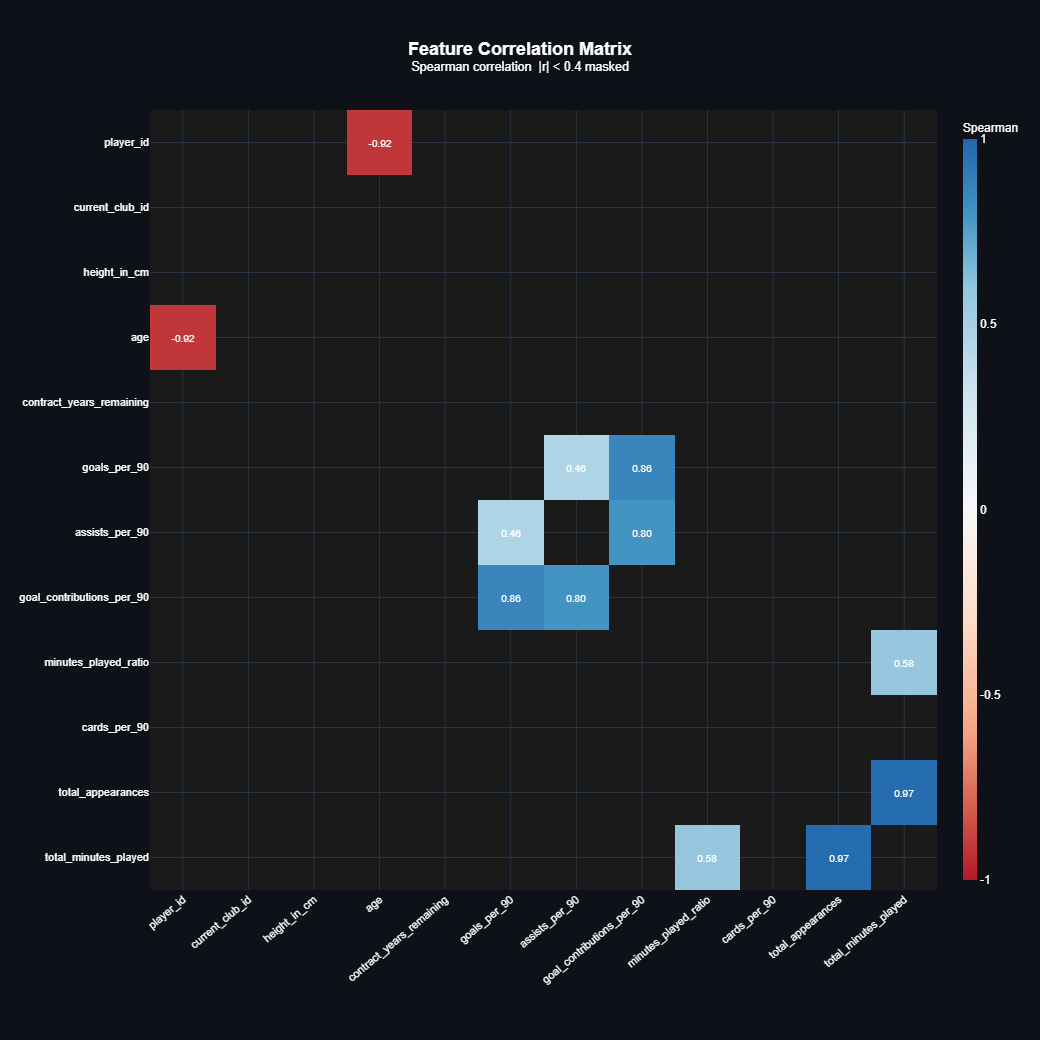

In [ ]:
test_correlation = correlation_heatmap(df=test,threshold=0.4, method='spearman')
test_correlation

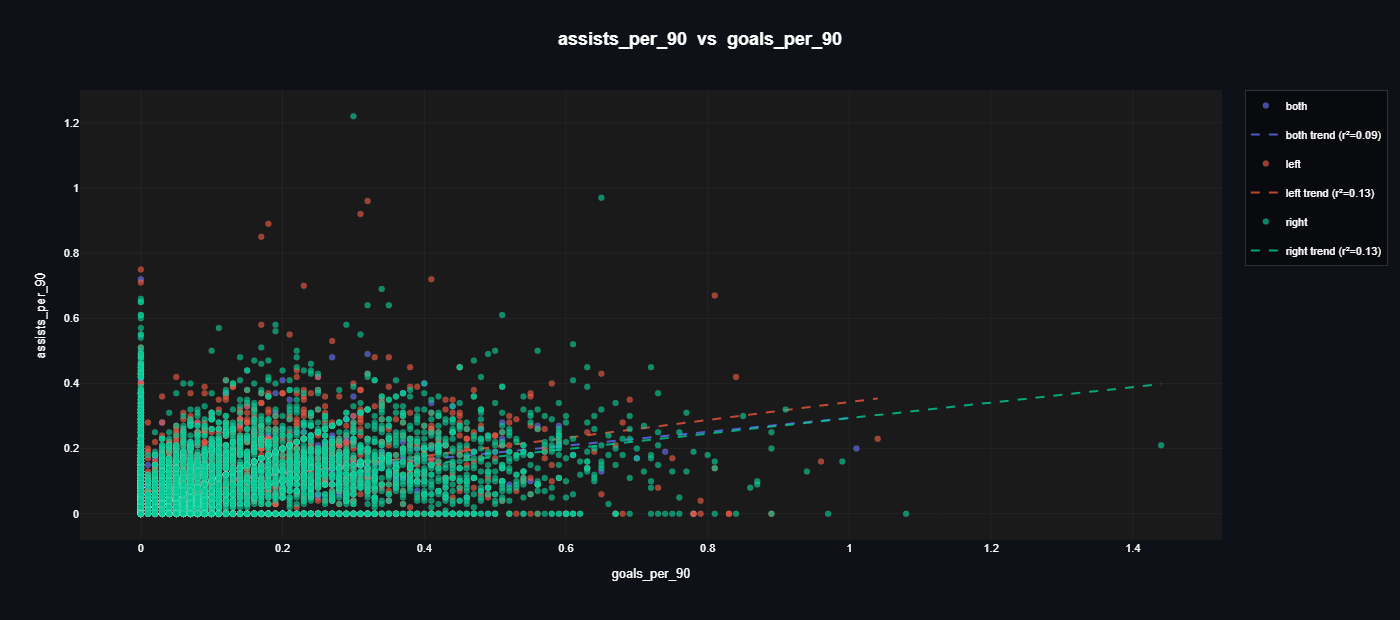

In [ ]:
test_scatter = scatter_plot(df=test, x='goals_per_90', y='assists_per_90', color_by='foot')
test_scatter

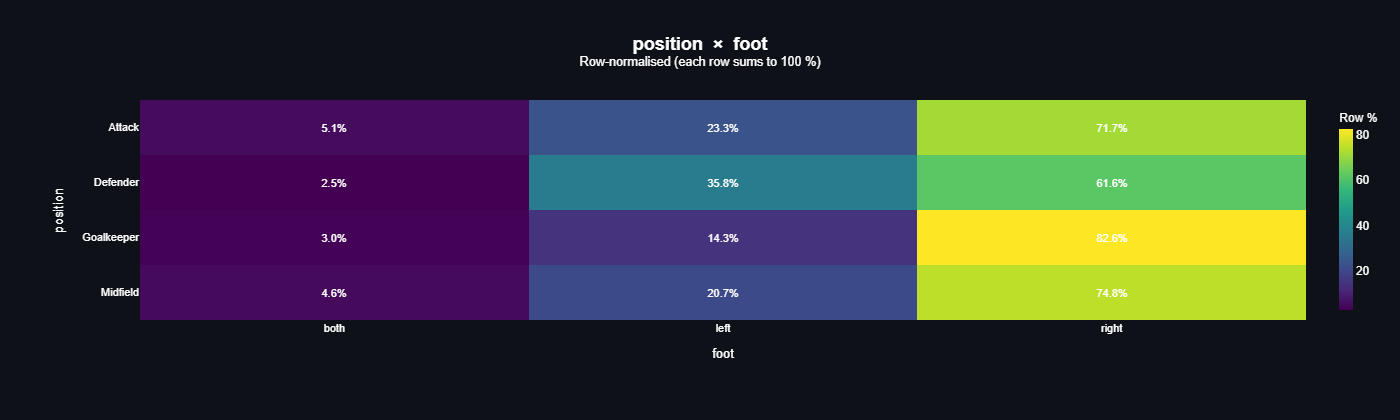

In [ ]:
test_crosstab = cross_tab_heatmap(df=test, col1='position', col2='foot')
test_crosstab

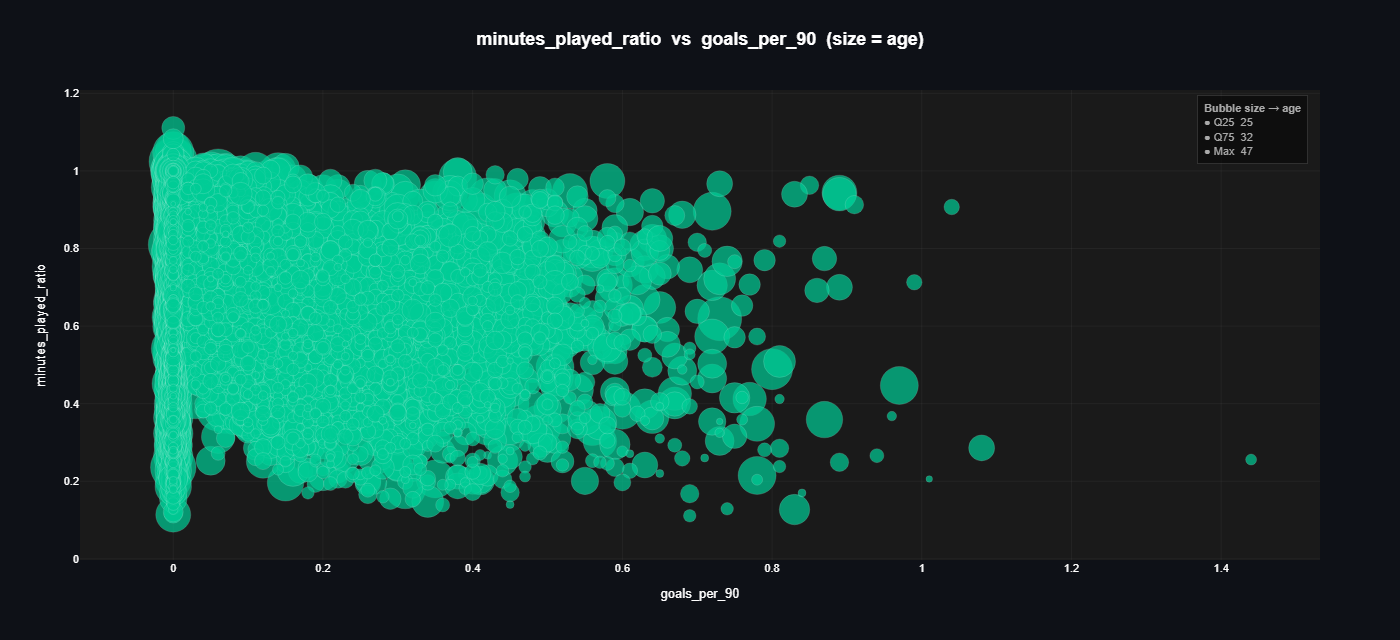

In [ ]:
test_bubble = bubble_plot(df=test, x='goals_per_90', y='minutes_played_ratio', size='age')
test_bubble

In [ ]:
test2 = run_query('select c.name, c.win_rate from clubs c')
test2.T

,0,1,2,3,4,5,6,7,8,9,...,416,417,418,419,420,421,422,423,424,425
name,Goverla Uzhgorod (- 2016),Karpaty Lviv (-2021),Beerschot AC,SC Bastia,Panthrakikos Komotini,RAEC Mons (- 2015),Panionios Athens,Amkar Perm,SC Beira-Mar,AEL Kalloni,...,Saint Mirren Football Club,FK Kolos Kovalivka,TSG 1899 Hoffenheim Fußball-Spielbetriebs GmbH,Royal Sporting Club Anderlecht,Venezia FC,CF Os Belenenses,Football Club Volendam,Atalanta Bergamasca Calcio S.p.a.,Moreirense Futebol Clube,West Bromwich Albion
win_rate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.329,0.324,0.345,0.478,0.167,NaN,0.2,0.508,0.318,0.143
